In [50]:
import scipy.stats as stats
import scipy.stats as chi2

import pandas as pd;
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('questionnaire.csv')
df.head()

,SEQN,ACD011A,ACD011B,ACD011C,ACD040,ACD110,ALQ101,ALQ110,ALQ120Q,ALQ120U,...,WHD080U,WHD080L,WHD110,WHD120,WHD130,WHD140,WHQ150,WHQ030M,WHQ500,WHQ520
0,73557,1.0,NaN,NaN,NaN,NaN,1.0,NaN,1.0,3.0,...,NaN,40.0,270.0,200.0,69.0,270.0,62.0,NaN,NaN,NaN
1,73558,1.0,NaN,NaN,NaN,NaN,1.0,NaN,7.0,1.0,...,NaN,NaN,240.0,250.0,72.0,250.0,25.0,NaN,NaN,NaN
2,73559,1.0,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,...,NaN,NaN,180.0,190.0,70.0,228.0,35.0,NaN,NaN,NaN
3,73560,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,3.0
4,73561,1.0,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,...,NaN,NaN,150.0,135.0,67.0,170.0,60.0,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10175 entries, 0 to 10174
Columns: 953 entries, SEQN to WHQ520
dtypes: float64(944), int64(7), str(2)
memory usage: 74.0 MB


In [4]:
confusion = 'DLQ040'   
ciggrate = 'SMD650'    

df = df[[confusion, ciggrate]]  
df.columns = ['confusion', 'ciggrate']

df.describe()

,confusion,ciggrate
count,8780.000000,1248.000000
mean,1.901253,11.989583
std,0.314328,40.446177
min,1.000000,1.000000
25%,2.000000,4.000000
50%,2.000000,10.000000
75%,2.000000,15.000000
max,9.000000,999.000000


In [5]:
df.head(10)

,confusion,ciggrate
0,2.0,NaN
1,2.0,1.0
2,2.0,NaN
3,2.0,NaN
4,2.0,NaN
5,2.0,NaN
6,NaN,NaN
7,2.0,NaN
8,2.0,NaN
9,2.0,1.0


In [6]:
df.groupby('confusion')['ciggrate'].sum()

confusion
1.0     2044.0
2.0    12919.0
7.0        0.0
9.0        0.0
Name: ciggrate, dtype: float64

## 1 means confusion ,2 means no-confusion 

In [7]:
df.isnull().sum() / len(df) * 100

confusion    13.710074
ciggrate     87.734644
dtype: float64

In [8]:
df['ciggrate'].value_counts(normalize = True) * 100

ciggrate
10.0     19.871795
20.0     17.948718
5.0       9.615385
1.0       8.573718
3.0       7.451923
2.0       6.650641
15.0      6.169872
4.0       5.208333
6.0       3.846154
7.0       3.205128
30.0      2.724359
12.0      2.403846
8.0       2.083333
40.0      0.961538
9.0       0.721154
25.0      0.400641
11.0      0.320513
13.0      0.320513
17.0      0.320513
18.0      0.240385
999.0     0.160256
50.0      0.160256
14.0      0.160256
16.0      0.080128
60.0      0.080128
27.0      0.080128
90.0      0.080128
29.0      0.080128
28.0      0.080128
Name: proportion, dtype: float64

In [9]:
df['confusion'].value_counts(normalize = True) * 100

confusion
2.0    89.965831
1.0    10.011390
7.0     0.011390
9.0     0.011390
Name: proportion, dtype: float64

In [10]:
df['ciggrate'].describe()

count    1248.000000
mean       11.989583
std        40.446177
min         1.000000
25%         4.000000
50%        10.000000
75%        15.000000
max       999.000000
Name: ciggrate, dtype: float64

In [11]:
df['confusion'].describe()

count    8780.000000
mean        1.901253
std         0.314328
min         1.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         9.000000
Name: confusion, dtype: float64

In [12]:
df['ciggrate'].unique()

array([ nan,   1.,  25.,  20.,  10.,   2.,   5.,   4.,  30.,   3.,   9.,
        15.,   7.,  12.,   6.,   8., 999.,  11.,  40.,  18.,  50.,  13.,
        16.,  17.,  14.,  60.,  27.,  90.,  29.,  28.])

In [13]:
df['confusion'].unique()

array([ 2., nan,  1.,  7.,  9.])

In [14]:
confusion_mode = df['confusion'].dropna().mode()
df.fillna({'confusion': confusion_mode[0]}, inplace = True)

,confusion,ciggrate
0,2.0,NaN
1,2.0,1.0
2,2.0,NaN
3,2.0,NaN
4,2.0,NaN
...,...,...
10170,2.0,NaN
10171,2.0,NaN
10172,2.0,NaN
10173,2.0,NaN


In [15]:
df.fillna({'ciggrate': 0}, inplace = True)

,confusion,ciggrate
0,2.0,0.0
1,2.0,1.0
2,2.0,0.0
3,2.0,0.0
4,2.0,0.0
...,...,...
10170,2.0,0.0
10171,2.0,0.0
10172,2.0,0.0
10173,2.0,0.0


In [16]:
smoker = df['ciggrate'].value_counts()
smoker

ciggrate
0.0      8927
10.0      248
20.0      224
5.0       120
1.0       107
3.0        93
2.0        83
15.0       77
4.0        65
6.0        48
7.0        40
30.0       34
12.0       30
8.0        26
40.0       12
9.0         9
25.0        5
11.0        4
13.0        4
17.0        4
18.0        3
999.0       2
50.0        2
14.0        2
16.0        1
60.0        1
27.0        1
90.0        1
29.0        1
28.0        1
Name: count, dtype: int64

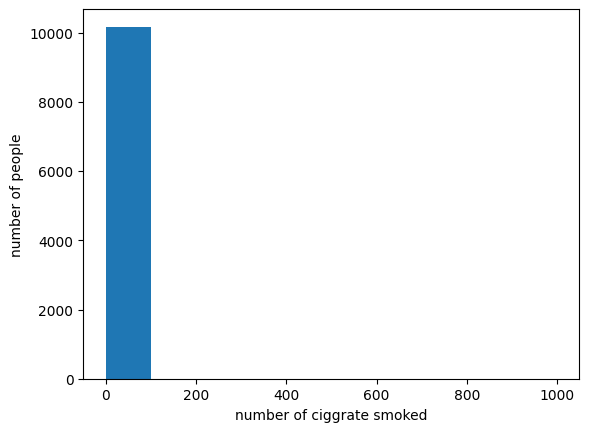

In [17]:
# fig, ax = plt.subplots(1,2, figsize=(10,6))
plt.hist(df['ciggrate'] )
plt.xlabel('number of ciggrate smoked')
plt.ylabel('number of people')
plt.show()

In [18]:
# apply IQR on the tabel

# 1. Split the data
non_smokers = df[df['ciggrate'] == 0]
smokers = df[df['ciggrate'] > 0]

# 2. Calculate IQR ONLY on the smokers
Q1 = smokers['ciggrate'].quantile(0.25)
Q3 = smokers['ciggrate'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 3. Filter outliers ONLY from the smoker group
smokers_clean = smokers[(smokers['ciggrate'] >= lower) & (smokers['ciggrate'] <= upper)]

# 4. Combine Non-smokers + Clean Smokers back together
df = pd.concat([non_smokers, smokers_clean])

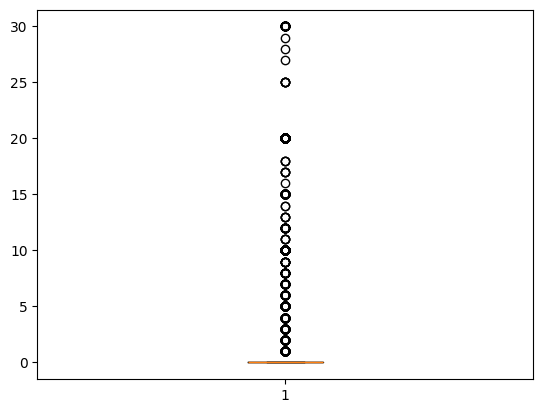

In [19]:
plt.boxplot(df['ciggrate'])
plt.show()

In [20]:
df['ciggrate'].value_counts()

ciggrate
0.0     8927
10.0     248
20.0     224
5.0      120
1.0      107
3.0       93
2.0       83
15.0      77
4.0       65
6.0       48
7.0       40
30.0      34
12.0      30
8.0       26
9.0        9
25.0       5
11.0       4
13.0       4
17.0       4
18.0       3
14.0       2
16.0       1
27.0       1
29.0       1
28.0       1
Name: count, dtype: int64

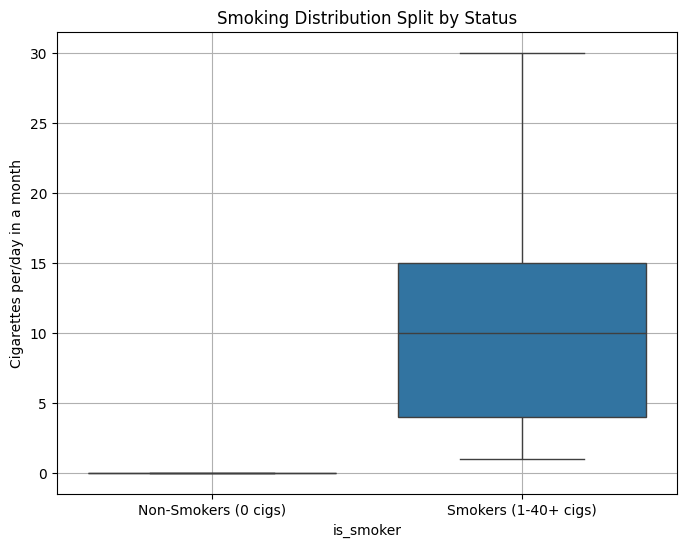

In [21]:
# Create a boolean column if you haven't already
df['is_smoker'] = df['ciggrate'] > 0

# Plot side-by-side boxplots
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_smoker', y='ciggrate', data=df)
plt.xticks([0, 1], ['Non-Smokers (0 cigs)', 'Smokers (1-40+ cigs)'])
plt.ylabel('Cigarettes per/day in a month')

plt.grid(True)
plt.title('Smoking Distribution Split by Status')
plt.show()

From above we can say that people who are smoker smokes as following:

50% smoke 10 cig a day, 75% smoke 15 cig a day, 25% smoke 4 cig a day 

In [22]:
confusion = df.groupby('confusion')['ciggrate'].sum()
confusion

confusion
1.0     1924.0
2.0    10311.0
7.0        0.0
9.0        0.0
Name: ciggrate, dtype: float64

confusion have 1,2,7,9. I have smoker and non smoker. am looking for if smoking cause the confusion so non smoker dont make scence to be here. because the factore that is supposed to determine is not even here. so I should remove te non smoker, and check for smoker only

In [23]:
df = df[df['confusion'].isin([1, 2])]
df['confusion'].unique()

array([2., 1.])

In [24]:
df['ciggrate'].unique()

array([ 0.,  1., 25., 20., 10.,  2.,  5.,  4., 30.,  3.,  9., 15.,  7.,
       12.,  6.,  8., 11., 18., 13., 16., 17., 14., 27., 29., 28.])

In [25]:
cause = pd.crosstab(df['confusion'], df['ciggrate'], normalize = True) * 100
cause

ciggrate,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,15.0,16.0,17.0,18.0,20.0,25.0,27.0,28.0,29.0,30.0
confusion,,,,,,,,,,,,,,,,,,,,,
1.0,6.95224,0.167405,0.078779,0.088626,0.078779,0.137863,0.049237,0.019695,0.029542,0.039389,...,0.108321,0.000000,0.009847,0.009847,0.393895,0.000000,0.000000,0.000000,0.000000,0.088626
2.0,80.93550,0.886263,0.738552,0.827179,0.561300,1.043821,0.423437,0.374200,0.226489,0.049237,...,0.649926,0.009847,0.029542,0.019695,1.811915,0.049237,0.009847,0.009847,0.009847,0.246184


In [26]:
def smoke_tier(smoke_column):
    Tier = [];
    for amount in df[smoke_column]:
        if amount == 0 :
            Tier.append('non-smoker')
        elif 1 <= amount <= 5:
            Tier.append('light-smoker')
        elif 6 <= amount <= 10:
            Tier.append('moderate')
        elif 11 <= amount <= 20:
            Tier.append('Heavy')
        else:
            Tier.append('Dangerous amount')
    return Tier;

df['Smoking_lvl'] = smoke_tier('ciggrate')

In [27]:
df.head()

,confusion,ciggrate,is_smoker,Smoking_lvl
0,2.0,0.0,False,non-smoker
2,2.0,0.0,False,non-smoker
3,2.0,0.0,False,non-smoker
4,2.0,0.0,False,non-smoker
5,2.0,0.0,False,non-smoker


In [41]:
cause_confusion = pd.crosstab(df['confusion'], df['Smoking_lvl'])
cause_confusion

Smoking_lvl,Dangerous amount,Heavy,light-smoker,moderate,non-smoker
confusion,,,,,
1.0,9,56,56,49,706
2.0,33,293,412,322,8219


As the data is showing that as the smoking amount is increase, it is creating problems with thinking and causing confusion

CHI-square Test will performed on this data set, reason being:
- There is 2 categorical data and have to find the relation between them which is smoking_lvl and confusion.
## Hypothesis will be :
- Null hypothesis -: There is no significance in decision making or confusion and amount of smoking a person do.
- Alt hypothesis -: There is significance in amount of ciggrate smoking and confusion or decision making.

In [42]:
cause_confusion.values

array([[   9,   56,   56,   49,  706],
       [  33,  293,  412,  322, 8219]])

In [45]:
val = stats.chi2_contingency(cause_confusion)
val

Chi2ContingencyResult(statistic=np.float64(55.41177359916897), pvalue=np.float64(2.6635276810352442e-11), dof=4, expected_freq=array([[3.62304284e+00, 3.01057607e+01, 4.03710487e+01, 3.20035451e+01,
        7.69896603e+02],
       [3.83769572e+01, 3.18894239e+02, 4.27628951e+02, 3.38996455e+02,
        8.15510340e+03]]))

In [48]:
val[2]

4

In [46]:
pval = val[1]
if pval < 0.05:
    print('True')

True


In [47]:
statisticval = val[0]
if statisticval > 9.48773:
    print('True')

True


In [53]:
criticalval = chi2.chi2.ppf(q = 1 - 0.05, df = val[2])
print(criticalval)

9.487729036781154


In [54]:
if pval < 0.05:
    print('Reject the null hypothesis');
else:
    print('accept the null hypothesis');

Reject the null hypothesis


In [55]:
if statisticval >= criticalval :
    print('Reject the null hypothesis');
else:
    print('accept the null hypothesis');

Reject the null hypothesis


## Clearly we reject the null hypothesis, that means there is significance in the amount of ciggrate consuption and confusion 
- so more consuption of ciggrate show more confusion in people
- lesser consuption can improve in mental clarity

In [56]:
df.head()

,confusion,ciggrate,is_smoker,Smoking_lvl
0,2.0,0.0,False,non-smoker
2,2.0,0.0,False,non-smoker
3,2.0,0.0,False,non-smoker
4,2.0,0.0,False,non-smoker
5,2.0,0.0,False,non-smoker
